**Maliha Nazim Khan**

**House Price Prediction**
**Dataset:- California Housing**

**Model: 1. Decision Tree Regressor**

In [2]:
# STEP 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# STEP 2: Load Dataset
path = "/content/drive/MyDrive/Datasets/housing[1].csv"
df = pd.read_csv(path)
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [6]:
# STEP 3: Data Preprocessing

# Handle missing values
df.fillna({'total_bedrooms': df['total_bedrooms'].mean()}, inplace=True)
# Convert categorical column to numerical
df = pd.get_dummies(df, columns=['ocean_proximity'])

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [8]:
# STEP 4: Define Features and Target
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [9]:
# STEP 5A: Split Data (70% Train, 30% Test)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [10]:
# STEP 6A: Train Decision Tree Model (70-30)
dt_70 = DecisionTreeRegressor(random_state=42)
dt_70.fit(X_train_70, y_train_70)

DecisionTreeRegressor(random_state=42)

In [11]:
# STEP 7A: Predictions (70-30)
y_pred_30 = dt_70.predict(X_test_30)

In [12]:
# STEP 8A: Evaluation (70-30)
print("---- 70-30 Split ----")
print("MAE:", mean_absolute_error(y_test_30, y_pred_30))
print("MSE:", mean_squared_error(y_test_30, y_pred_30))
print("R2 Score:", r2_score(y_test_30, y_pred_30))

---- 70-30 Split ----
MAE: 44031.987241602066
MSE: 4823891004.984657
R2 Score: 0.632476678139823


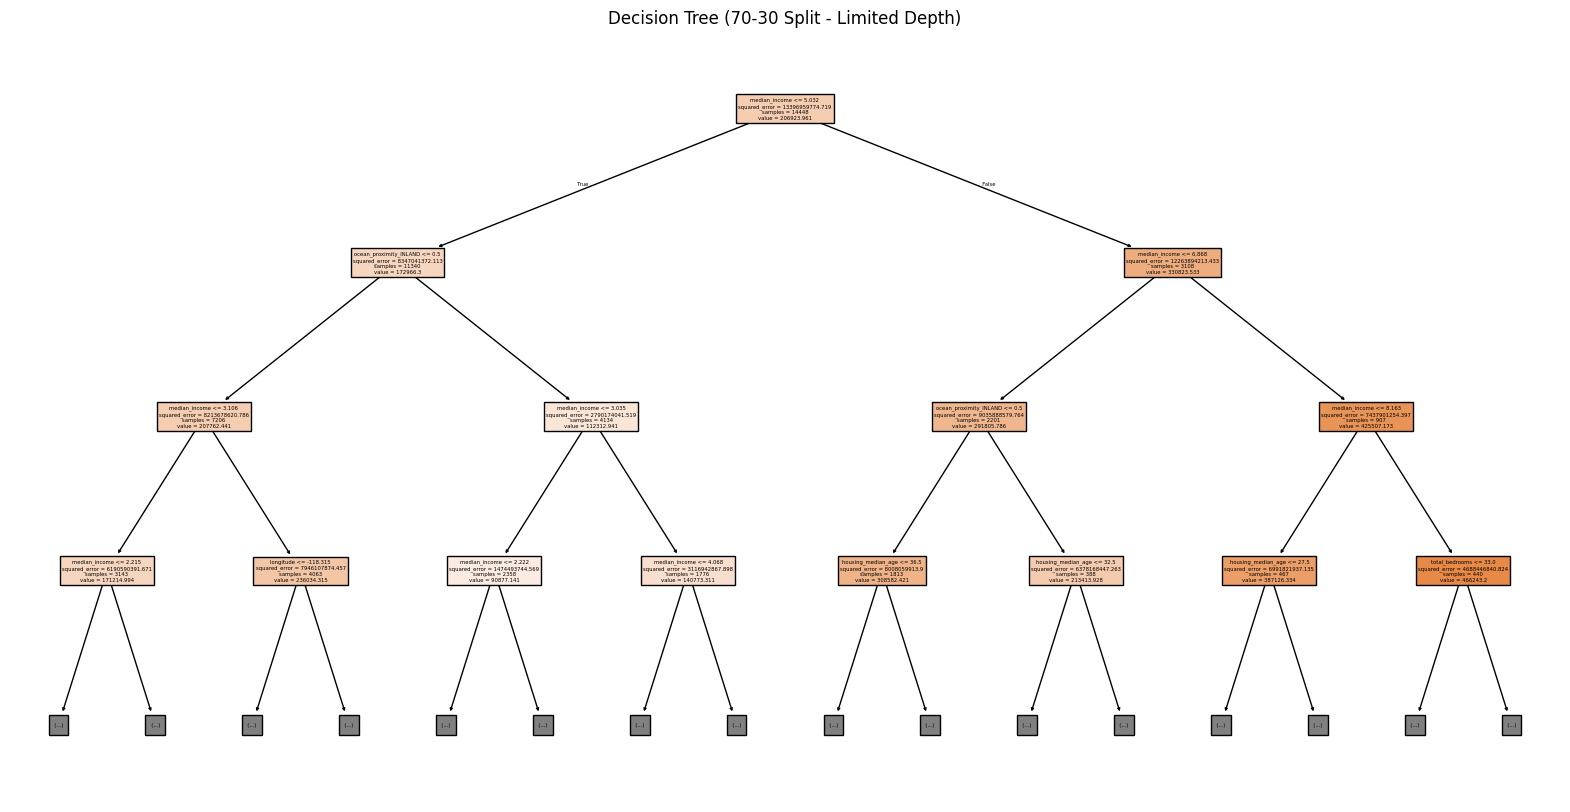

In [21]:
# STEP 9A VISUALIZATION: Decision Tree (70-30 with Depth Limit)
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt_70, filled=True, feature_names=X.columns, max_depth=3)
plt.title("Decision Tree (70-30 Split - Limited Depth)")
plt.show()

In [16]:
# STEP 5B: Split Data (80% Train, 20% Test)
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# STEP 6B: Train Decision Tree Model (80-20)
dt_80 = DecisionTreeRegressor(random_state=42)
dt_80.fit(X_train_80, y_train_80)

DecisionTreeRegressor(random_state=42)

In [18]:
# STEP 7B: Predictions (80-20)
y_pred_20 = dt_80.predict(X_test_20)

In [19]:
# STEP 8B: Evaluation (80-20)
print("\n---- 80-20 Split ----")
print("MAE:", mean_absolute_error(y_test_20, y_pred_20))
print("MSE:", mean_squared_error(y_test_20, y_pred_20))
print("R2 Score:", r2_score(y_test_20, y_pred_20))


---- 80-20 Split ----
MAE: 43655.37160852713
MSE: 4790624903.433624
R2 Score: 0.6344175762696174


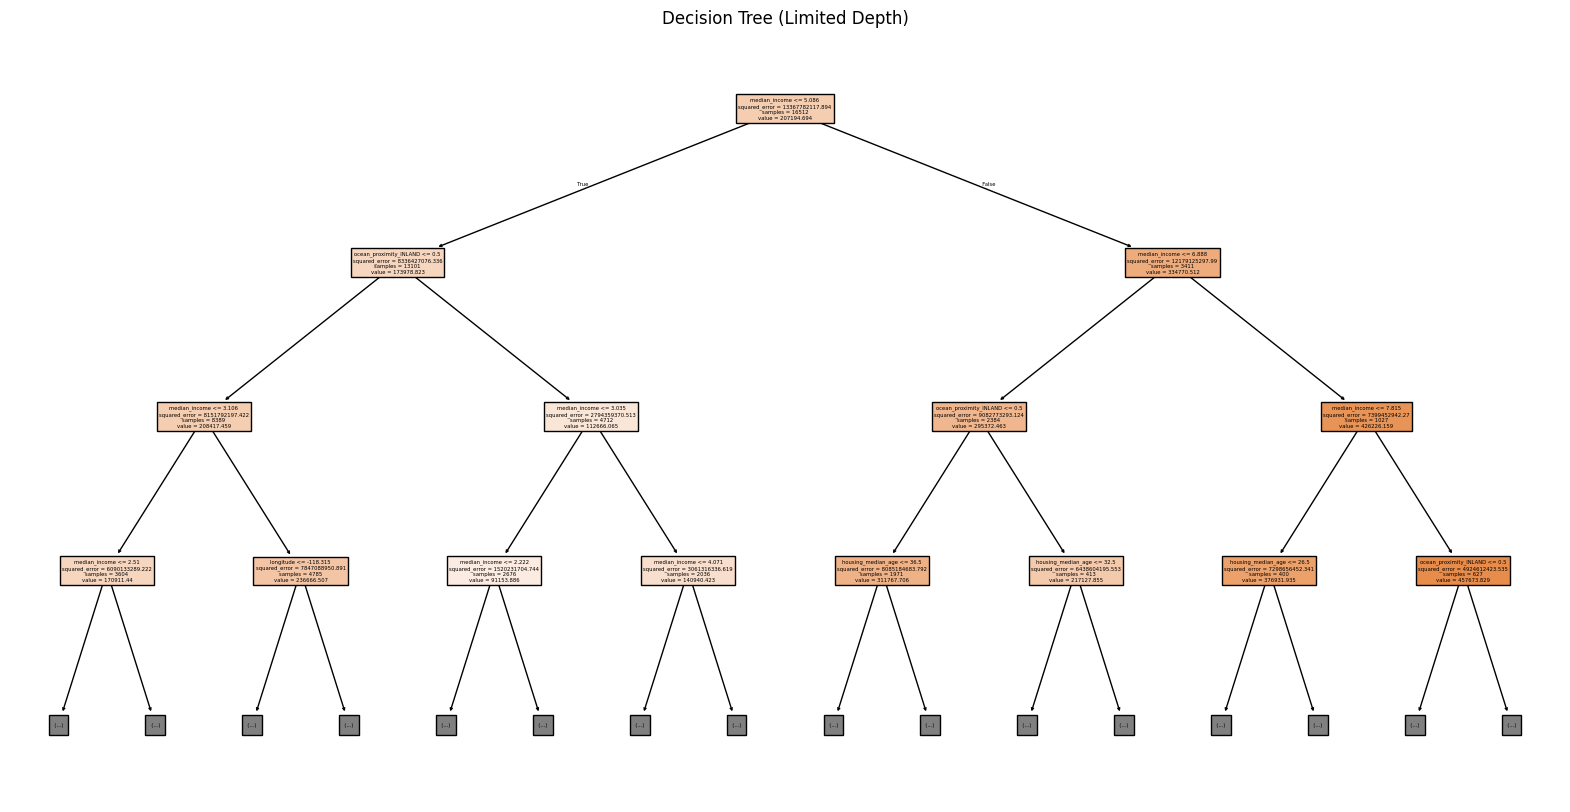

In [20]:
# STEP 9B (Visualization with Depth Limit)
plt.figure(figsize=(20,10))
plot_tree(dt_80, filled=True, feature_names=X.columns, max_depth=3)
plt.title("Decision Tree (Limited Depth)")
plt.show()

In [25]:
# STEP 10: Comparison Table (70-30 vs 80-20)

results = pd.DataFrame({
    'Split': ['70-30', '80-20'],
    'MAE': [
        mean_absolute_error(y_test_30, y_pred_30),
        mean_absolute_error(y_test_20, y_pred_20)
    ],
    'MSE': [
        mean_squared_error(y_test_30, y_pred_30),
        mean_squared_error(y_test_20, y_pred_20)
    ],
    'R2 Score': [
        r2_score(y_test_30, y_pred_30),
        r2_score(y_test_20, y_pred_20)
    ]
})

print("\nComparison of Splits:")
print(results)


Comparison of Splits:
   Split           MAE           MSE  R2 Score
0  70-30  44031.987242  4.823891e+09  0.632477
1  80-20  43655.371609  4.790625e+09  0.634418


In [39]:
# STEP 11: Best Split Conclusion

if results.loc[0, 'R2 Score'] > results.loc[1, 'R2 Score']:
    print("70-30 Split performs better")
else:
    print("80-20 Split performs better")

80-20 Split performs better


**Model 2:- Random Forest Regressor**

In [26]:
# STEP 12: Import Random Forest
from sklearn.ensemble import RandomForestRegressor
# STEP 13A: Train Random Forest (70-30)
rf_70 = RandomForestRegressor(random_state=42)
rf_70.fit(X_train_70, y_train_70)

RandomForestRegressor(random_state=42)

In [27]:
# STEP 14A: Predictions (70-30)
rf_pred_30 = rf_70.predict(X_test_30)

# STEP 15A: Evaluation (70-30)
print("\n---- Random Forest (70-30 Split) ----")
print("MAE:", mean_absolute_error(y_test_30, rf_pred_30))
print("MSE:", mean_squared_error(y_test_30, rf_pred_30))
print("R2 Score:", r2_score(y_test_30, rf_pred_30))


---- Random Forest (70-30 Split) ----
MAE: 31745.81883074935
MSE: 2367237039.0052147
R2 Score: 0.8196445941032591


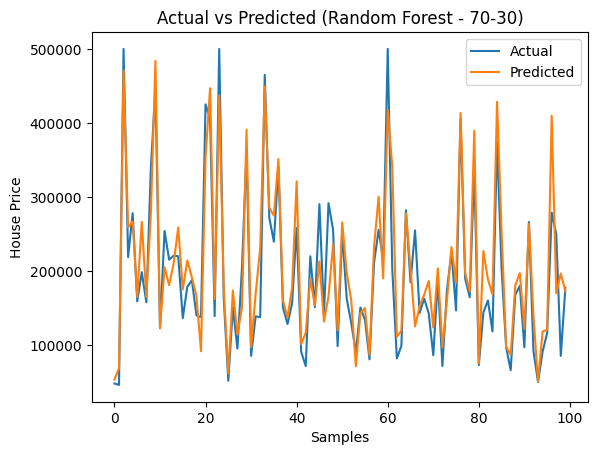

In [29]:
# STEP 16A: Visualization (70-30)
plt.figure()

# take first 100 values for better clarity
plt.plot(y_test_30.values[:100], label="Actual")
plt.plot(rf_pred_30[:100], label="Predicted")

plt.title("Actual vs Predicted (Random Forest - 70-30)")
plt.xlabel("Samples")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [30]:
# STEP 13B: Train Random Forest (80-20)
rf_80 = RandomForestRegressor(random_state=42)
rf_80.fit(X_train_80, y_train_80)

RandomForestRegressor(random_state=42)

In [31]:
# STEP 14B: Predictions (80-20)
rf_pred_20 = rf_80.predict(X_test_20)

# STEP 15B: Evaluation (80-20)
print("\n---- Random Forest (80-20 Split) ----")
print("MAE:", mean_absolute_error(y_test_20, rf_pred_20))
print("MSE:", mean_squared_error(y_test_20, rf_pred_20))
print("R2 Score:", r2_score(y_test_20, rf_pred_20))


---- Random Forest (80-20 Split) ----
MAE: 31667.989481589146
MSE: 2397315306.588798
R2 Score: 0.8170559461667481


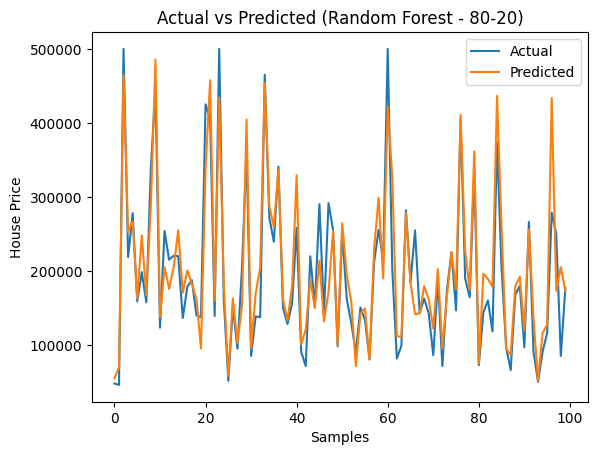

In [32]:
# STEP 16B: Visualization (80-20)
plt.figure()

# take only first 100 values for clarity
plt.plot(y_test_20.values[:100], label="Actual")
plt.plot(rf_pred_20[:100], label="Predicted")

plt.title("Actual vs Predicted (Random Forest - 80-20)")
plt.xlabel("Samples")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [38]:
# STEP 17: Simple Comparison (70-30 vs 80-20)
# 70-30 metrics
mae_70 = mean_absolute_error(y_test_30, rf_pred_30)
mse_70 = mean_squared_error(y_test_30, rf_pred_30)
r2_70 = r2_score(y_test_30, rf_pred_30)

# 80-20 metrics
mae_80 = mean_absolute_error(y_test_20, rf_pred_20)
mse_80 = mean_squared_error(y_test_20, rf_pred_20)
r2_80 = r2_score(y_test_20, rf_pred_20)

# Print comparison
print("Comparison of Splits (Random Forest)")
if r2_80 > r2_70:
    print("\n80-20 Split performs better")
else:
    print("\n70-30 Split performs better")

Comparison of Splits (Random Forest)

70-30 Split performs better


**Model 3:- KNN Regressor**

In [40]:
# STEP 18: Import KNN Regressor & Feature Scaling (IMPORTANT for KNN)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_70_scaled = scaler.fit_transform(X_train_70)
X_test_30_scaled = scaler.transform(X_test_30)

X_train_80_scaled = scaler.fit_transform(X_train_80)
X_test_20_scaled = scaler.transform(X_test_20)

In [41]:
# STEP 19A: Train KNN (70-30)
knn_70 = KNeighborsRegressor(n_neighbors=5)
knn_70.fit(X_train_70_scaled, y_train_70)

KNeighborsRegressor()

In [42]:
# STEP 20A: Predictions (70-30)
knn_pred_30 = knn_70.predict(X_test_30_scaled)

In [43]:
# STEP 21A: Evaluation (70-30)
print("\n---- KNN (70-30 Split) ----")
print("MAE:", mean_absolute_error(y_test_30, knn_pred_30))
print("MSE:", mean_squared_error(y_test_30, knn_pred_30))
print("R2 Score:", r2_score(y_test_30, knn_pred_30))


---- KNN (70-30 Split) ----
MAE: 41469.00184108527
MSE: 3817700018.0357304
R2 Score: 0.7091365059773751


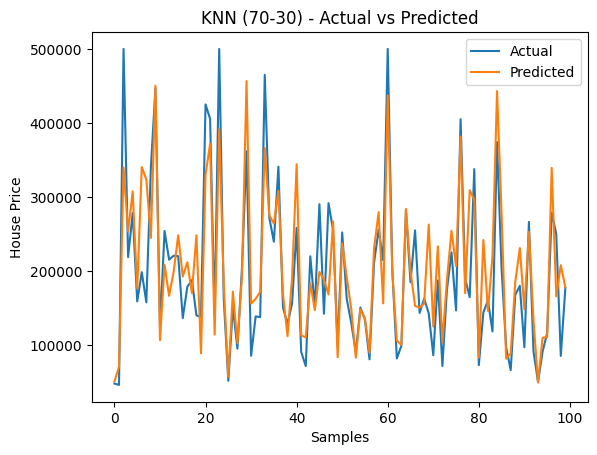

In [52]:
# STEP 22A: VISUALIZATION (70-30)
plt.figure()

plt.plot(y_test_30.values[:100], label="Actual")
plt.plot(knn_pred_30[:100], label="Predicted")

plt.title("KNN (70-30) - Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [44]:
# STEP 19B: Train KNN (80-20)
knn_80 = KNeighborsRegressor(n_neighbors=5)
knn_80.fit(X_train_80_scaled, y_train_80)


KNeighborsRegressor()

In [45]:
# STEP 20B: Predictions (80-20)
knn_pred_20 = knn_80.predict(X_test_20_scaled)

In [46]:
# STEP 21B: Evaluation (80-20)
print("\n---- KNN (80-20 Split) ----")
print("MAE:", mean_absolute_error(y_test_20, knn_pred_20))
print("MSE:", mean_squared_error(y_test_20, knn_pred_20))
print("R2 Score:", r2_score(y_test_20, knn_pred_20))


---- KNN (80-20 Split) ----
MAE: 40966.08410852713
MSE: 3785007031.983973
R2 Score: 0.7111583410344924


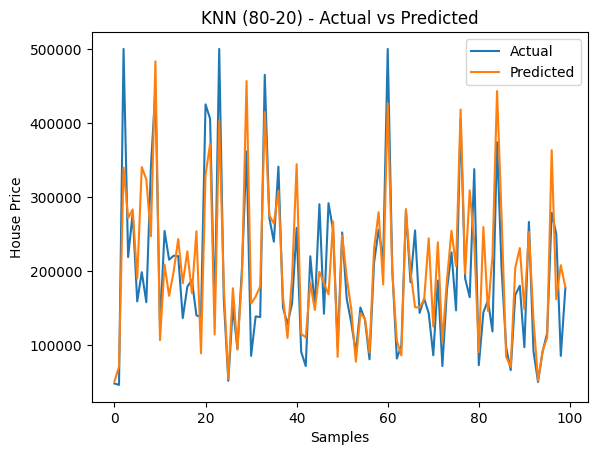

In [54]:
# STEP 22B: VISUALIZATION (80-20)
plt.figure()

plt.plot(y_test_20.values[:100], label="Actual")
plt.plot(knn_pred_20[:100], label="Predicted")

plt.title("KNN (80-20) - Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [53]:
# STEP 23: Comparison (KNN)

# 70-30
mae_knn_70 = mean_absolute_error(y_test_30, knn_pred_30)
r2_knn_70 = r2_score(y_test_30, knn_pred_30)

# 80-20
mae_knn_80 = mean_absolute_error(y_test_20, knn_pred_20)
r2_knn_80 = r2_score(y_test_20, knn_pred_20)

print("KNN Comparison")

print("\n70-30 Split -> MAE:", mae_knn_70, " R2:", r2_knn_70)
print("80-20 Split -> MAE:", mae_knn_80, " R2:", r2_knn_80)

# Best split
if r2_knn_80 > r2_knn_70:
    print("\n80-20 Split performs better for KNN")
else:
    print("\n70-30 Split performs better for KNN")

KNN Comparison

70-30 Split -> MAE: 41469.00184108527  R2: 0.7091365059773751
80-20 Split -> MAE: 40966.08410852713  R2: 0.7111583410344924

80-20 Split performs better for KNN


**Final Comparison between all three models implemented.**

In [55]:
# STEP24: Final Comparison of Models

print("\n===== FINAL MODEL COMPARISON =====")

# Decision Tree
dt_r2_70 = r2_score(y_test_30, y_pred_30)
dt_r2_80 = r2_score(y_test_20, y_pred_20)

# Random Forest
rf_r2_70 = r2_score(y_test_30, rf_pred_30)
rf_r2_80 = r2_score(y_test_20, rf_pred_20)

# KNN
knn_r2_70 = r2_score(y_test_30, knn_pred_30)
knn_r2_80 = r2_score(y_test_20, knn_pred_20)

# Print Results
print("\nDecision Tree R2:")
print("70-30:", dt_r2_70)
print("80-20:", dt_r2_80)

print("\nRandom Forest R2:")
print("70-30:", rf_r2_70)
print("80-20:", rf_r2_80)

print("\nKNN R2:")
print("70-30:", knn_r2_70)
print("80-20:", knn_r2_80)


===== FINAL MODEL COMPARISON =====

Decision Tree R2:
70-30: 0.632476678139823
80-20: 0.6344175762696174

Random Forest R2:
70-30: 0.8196445941032591
80-20: 0.8170559461667481

KNN R2:
70-30: 0.7091365059773751
80-20: 0.7111583410344924


In [56]:
# STEP25: Find Best Model

models = {
    "Decision Tree": dt_r2_80,
    "Random Forest": rf_r2_80,
    "KNN": knn_r2_80
}

best_model = max(models, key=models.get)

print("\nBest Model is:", best_model)


Best Model is: Random Forest
